In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/'

# Check if the directory exists
if os.path.exists(dataset_path):
    print(f"Listing all contents of: {dataset_path}")
    for root, dirs, files in os.walk(dataset_path):
        # Print the current directory
        print(f"Directory: {root}")
        # Print subdirectories
        if dirs:
            print(f"  Subdirectories: {dirs}")
        # Print files
        if files:
            print(f"  Files: {files}")
        # Removed the break to show all nested files/dirs
else:
    print(f"Directory not found: {dataset_path}. Please ensure it exists and Drive is mounted correctly.")

Listing all contents of: /content/drive/MyDrive/Deep SAR (SOS) Dataset/
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/
  Subdirectories: ['dataset']
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset
  Subdirectories: ['images', 'masks']
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images
  Subdirectories: ['val', 'train']
  Files: ['.DS_Store']
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/val
  Files: ['sentinel_11.png', 'palsar_485.png', 'palsar_532.png', 'palsar_308.png', 'sentinel_313.png', 'palsar_693.png', 'palsar_240.png', 'palsar_268.png', 'palsar_320.png', 'sentinel_307.png', 'palsar_20.png', 'palsar_686.png', 'palsar_137.png', 'palsar_651.png', 'palsar_678.png', 'palsar_35.png', 'palsar_644.png', 'sentinel_138.png', 'palsar_123.png', 'sentinel_110.png', 'palsar_136.png', 'palsar_34.png', 'palsar_679.png', 'palsar_645.png', 'sentinel_105.png', 'palsar_692.png', 'palsar_122.png', 'palsar_650.png', 'sentinel

### Dataset Structure Analysis

Based on the output of the `os.walk` command, the dataset is organized in the following hierarchical structure:

*   **`/content/drive/MyDrive/Deep SAR (SOS) Dataset/`** (Top-level directory)
    *   **`dataset/`** (Main dataset folder)
        *   **`images/`** (Contains image files)
            *   **`val/`** (Contains validation images, e.g., `sentinel_11.png`, `palsar_485.png`)
            *   **`train/`** (Contains training images, e.g., `palsar_2049.png`, `sentinel_2582.png`)
        *   **`masks/`** (Likely contains corresponding mask files for the images, though files are not listed in the current output for this directory, the structure implies their presence)
            *   **`val/`**
            *   **`train/`**

This structure clearly separates the image data from its corresponding masks, and further divides both into training and validation sets, which is typical for machine learning tasks involving image segmentation or classification.

In [1]:
import os

dataset_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/'
masks_path = os.path.join(dataset_path, 'dataset', 'masks')

# Check if the directory exists
if os.path.exists(masks_path):
    print(f"Listing all contents of: {masks_path}")
    for root, dirs, files in os.walk(masks_path):
        # Print the current directory
        print(f"Directory: {root}")
        # Print subdirectories
        if dirs:
            print(f"  Subdirectories: {dirs}")
        # Print files
        if files:
            print(f"  Files: {files}")
else:
    print(f"Directory not found: {masks_path}. Please ensure it exists and Drive is mounted correctly.")

Listing all contents of: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks
  Subdirectories: ['__MACOSX', 'masks']
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/__MACOSX
  Subdirectories: ['masks']
  Files: ['._masks']
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/__MACOSX/masks
  Subdirectories: ['val', 'train']
  Files: ['._val', '._.DS_Store', '._train']
Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/__MACOSX/masks/val
  Files: ['._sentinel_705.png', '._sentinel_275.png', '._sentinel_261.png', '._palsar_722.png', '._sentinel_711.png', '._sentinel_17.png', '._sentinel_739.png', '._sentinel_715.png', '._sentinel_513.png', '._palsar_246.png', '._palsar_281.png', '._sentinel_507.png', '._palsar_291.png', '._palsar_252.png', '._sentinel_329.png', '._palsar_1.png', '._sentinel_103.png', '._palsar_326.png', '._sentinel_665.png', '._palsa

**Reasoning**:
To analyze the file alignment between images and masks for both training and validation sets, I need to extract the filenames from the relevant directories. I will iterate through the `images` and `masks` directories to collect all filenames, excluding any metadata files. Then, I will compare the file counts and check for exact filename matches for each split.



In [2]:
import os

dataset_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/'

images_train_path = os.path.join(dataset_path, 'dataset', 'images', 'train')
images_val_path = os.path.join(dataset_path, 'dataset', 'images', 'val')
masks_train_path = os.path.join(dataset_path, 'dataset', 'masks', 'masks', 'train')
masks_val_path = os.path.join(dataset_path, 'dataset', 'masks', 'masks', 'val')


def get_filenames(path, strip_prefix=None):
    filenames = set()
    if os.path.exists(path):
        for root, _, files in os.walk(path):
            for file in files:
                # Exclude macOS metadata files like .DS_Store or files starting with ._
                if not file.startswith('.') and file.endswith('.png'):
                    if strip_prefix and file.startswith(strip_prefix):
                        filenames.add(file[len(strip_prefix):])
                    else:
                        filenames.add(file)
    return filenames

# Get filenames for images
images_train_files = get_filenames(images_train_path)
images_val_files = get_filenames(images_val_path)

# Get filenames for masks, stripping the '._' prefix from __MACOSX files if present
# From the os.walk output, files in masks/__MACOSX/masks/train/ and masks/__MACOSX/masks/val/
# had '._' prefix. The main masks/masks/train and masks/masks/val directly contain files without the prefix.
# Need to adjust logic to fetch files from the correct masks path based on the previous output

# Re-inspecting the os.walk output for masks, the actual files are in
# Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val
# Directory: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train
# these do NOT have the ._ prefix, the ._ files are in __MACOSX directories which are invalid.

masks_train_files = get_filenames(masks_train_path)
masks_val_files = get_filenames(masks_val_path)


# Compare counts
print(f"--- File Counts ---")
print(f"Images Train: {len(images_train_files)}")
print(f"Masks Train:  {len(masks_train_files)}")
print(f"Images Val:   {len(images_val_files)}")
print(f"Masks Val:    {len(masks_val_files)}")

# Compare file names for training set
missing_in_masks_train = images_train_files - masks_train_files
missing_in_images_train = masks_train_files - images_train_files

print(f"\n--- Training Set Alignment ---")
print(f"Files in images/train but not in masks/train: {len(missing_in_masks_train)}")
print(f"Files in masks/train but not in images/train: {len(missing_in_images_train)}")

# Compare file names for validation set
missing_in_masks_val = images_val_files - masks_val_files
missing_in_images_val = masks_val_files - images_val_files

print(f"\n--- Validation Set Alignment ---")
print(f"Files in images/val but not in masks/val: {len(missing_in_masks_val)}")
print(f"Files in masks/val but not in images/val: {len(missing_in_images_val)}")

# Check for specific missing files if any (show first few if many)
if missing_in_masks_train: print(f"  Examples missing in masks/train: {list(missing_in_masks_train)[:5]}")
if missing_in_images_train: print(f"  Examples missing in images/train: {list(missing_in_images_train)[:5]}")
if missing_in_masks_val: print(f"  Examples missing in masks/val: {list(missing_in_masks_val)[:5]}")
if missing_in_images_val: print(f"  Examples missing in images/val: {list(missing_in_images_val)[:5]}")

--- File Counts ---
Images Train: 6455
Masks Train:  6459
Images Val:   1389
Masks Val:    1615

--- Training Set Alignment ---
Files in images/train but not in masks/train: 0
Files in masks/train but not in images/train: 4

--- Validation Set Alignment ---
Files in images/val but not in masks/val: 0
Files in masks/val but not in images/val: 226
  Examples missing in images/train: ['palsar_1392 (1).png', 'palsar_1393 (1).png', 'palsar_1345 (1).png', 'palsar_135 (1).png']
  Examples missing in images/val: ['sentinel_711.png', 'sentinel_74.png', 'sentinel_705.png', 'sentinel_88.png', 'sentinel_690.png']


### Dataset Alignment Summary

Based on the comparison of filenames between the `images` and `masks` directories for both training and validation sets, the following observations were made:

*   **Training Set Alignment**:
    *   All `images/train` files have a corresponding mask in `masks/train` (0 missing in masks).
    *   However, 4 mask files in `masks/train` do not have a corresponding image file in `images/train`. The example names `['palsar_1392 (1).png', 'palsar_1393 (1).png', 'palsar_1345 (1).png', 'palsar_135 (1).png']` suggest these might be duplicates or incorrectly named files within the mask folder that include a `(1)` suffix. These files should ideally be removed from the mask folder or their corresponding images renamed if they exist.

*   **Validation Set Alignment**:
    *   All `images/val` files have a corresponding mask in `masks/val` (0 missing in masks).
    *   A significant discrepancy was found in the validation set: 226 mask files in `masks/val` do not have a corresponding image file in `images/val`. Examples like `['sentinel_711.png', 'sentinel_74.png', 'sentinel_705.png', 'sentinel_88.png', 'sentinel_690.png']` indicate that these are regular filenames, not necessarily duplicates with a special suffix.

**Conclusion and Next Steps**:

While the dataset guarantees that every image has a mask, there are mask files without corresponding images. These misaligned mask files could lead to errors during model training or evaluation if not handled properly. To ensure data integrity for an image segmentation task, it is crucial that every image has an exactly corresponding mask, and vice-versa. Therefore, the mask files that do not have a corresponding image file should be identified and either removed from the dataset or their missing image counterparts should be located and added.

For the next steps, it is recommended to:
1.  **Remove or address the 4 misaligned mask files in the training set**.
2.  **Identify and remove the 226 misaligned mask files in the validation set** to maintain a consistent 1:1 mapping between images and masks.

## Clean up misaligned mask files

### Subtask:
Remove mask files from the training and validation sets that do not have corresponding image files.


**Reasoning**:
I will construct the full paths for the misaligned mask files using the previously identified sets and paths, then remove these files using `os.remove()` to clean up the dataset.



In [3]:
import os

# Construct full paths and remove missing mask files from the training set
print("Removing misaligned mask files from training set...")
for filename in missing_in_images_train:
    file_path = os.path.join(masks_train_path, filename)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Removed: {file_path}")
    else:
        print(f"Warning: {file_path} not found for removal.")

# Construct full paths and remove missing mask files from the validation set
print("\nRemoving misaligned mask files from validation set...")
for filename in missing_in_images_val:
    file_path = os.path.join(masks_val_path, filename)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Removed: {file_path}")
    else:
        print(f"Warning: {file_path} not found for removal.")

# Re-run the file count and alignment check to confirm
# The get_filenames function is already defined in the previous cell

images_train_files = get_filenames(images_train_path)
images_val_files = get_filenames(images_val_path)
masks_train_files = get_filenames(masks_train_path)
masks_val_files = get_filenames(masks_val_path)

# Compare counts
print(f"\n--- Re-checked File Counts ---")
print(f"Images Train: {len(images_train_files)}")
print(f"Masks Train:  {len(masks_train_files)}")
print(f"Images Val:   {len(images_val_files)}")
print(f"Masks Val:    {len(masks_val_files)}")

# Compare file names for training set
missing_in_masks_train_recheck = images_train_files - masks_train_files
missing_in_images_train_recheck = masks_train_files - images_train_files

print(f"\n--- Re-checked Training Set Alignment ---")
print(f"Files in images/train but not in masks/train: {len(missing_in_masks_train_recheck)}")
print(f"Files in masks/train but not in images/train: {len(missing_in_images_train_recheck)}")

# Compare file names for validation set
missing_in_masks_val_recheck = images_val_files - masks_val_files
missing_in_images_val_recheck = masks_val_files - images_val_files

print(f"\n--- Re-checked Validation Set Alignment ---")
print(f"Files in images/val but not in masks/val: {len(missing_in_masks_val_recheck)}")
print(f"Files in masks/val but not in images/val: {len(missing_in_images_val_recheck)}")

# Confirm both are empty
if not missing_in_images_train_recheck and not missing_in_images_val_recheck:
    print("\nAll misaligned mask files successfully removed. Training and validation sets are now aligned.")
else:
    print("\nSome misaligned mask files still exist or new discrepancies found. Further investigation may be needed.")

Removing misaligned mask files from training set...
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train/palsar_1392 (1).png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train/palsar_1393 (1).png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train/palsar_1345 (1).png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train/palsar_135 (1).png

Removing misaligned mask files from validation set...
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val/sentinel_711.png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val/sentinel_74.png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val/sentinel_705.png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val/sentinel_88.png
Removed: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val/sentinel_690.png
Removed: /co

## Organize Dataset into Structured Format

### Subtask:
Create a test dataset by splitting a portion of the existing training data (images and masks) into a new test set, maintaining the current validation set.


**Reasoning**:
The first step is to define all necessary file paths for the new training, validation, and test sets, including creating the new test directories to store the split data.



In [4]:
import os
import shutil
import random

# Define paths for the new dataset structure
# Original training paths (these will become the new training paths after moving files)
new_images_train_path = images_train_path
new_masks_train_path = masks_train_path

# Validation paths remain the same
new_images_val_path = images_val_path
new_masks_val_path = masks_val_path

# New test paths
test_images_path = os.path.join(dataset_path, 'dataset', 'images', 'test')
test_masks_path = os.path.join(dataset_path, 'dataset', 'masks', 'test')

# Create new test directories if they don't exist
os.makedirs(test_images_path, exist_ok=True)
os.makedirs(test_masks_path, exist_ok=True)

print(f"New training images path: {new_images_train_path}")
print(f"New training masks path: {new_masks_train_path}")
print(f"New validation images path: {new_images_val_path}")
print(f"New validation masks path: {new_masks_val_path}")
print(f"New test images path: {test_images_path}")
print(f"New test masks path: {test_masks_path}")

print("Created test directories if they did not exist.")

New training images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train
New training masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train
New validation images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/val
New validation masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val
New test images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/test
New test masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/test
Created test directories if they did not exist.


**Reasoning**:
Now that the paths are defined and test directories created, the next step is to determine the split ratio, collect filenames from the original training set, and then randomly split these filenames into new training and test sets while ensuring corresponding image and mask files stay together.



In [5]:
import random
import shutil

# Define split ratio (e.g., 20% of original training data for the new test set)
TEST_SPLIT_RATIO = 0.2

# Get all image filenames from the original training set
original_train_images = sorted(list(get_filenames(new_images_train_path)))

# Ensure masks are aligned before splitting (this was handled in the previous step)
# We'll rely on the fact that all original_train_images now have corresponding masks

# Determine the number of files for the new test set
num_total_train_files = len(original_train_images)
num_test_files = int(num_total_train_files * TEST_SPLIT_RATIO)

# Randomly select filenames for the new test set
random.seed(42) # for reproducibility
test_filenames = random.sample(original_train_images, num_test_files)

# The remaining filenames will form the new training set
new_train_filenames = [f for f in original_train_images if f not in test_filenames]

print(f"Original training set size: {num_total_train_files}")
print(f"Number of files moved to new test set: {len(test_filenames)}")
print(f"New training set size: {len(new_train_filenames)}")

# Move selected files to the new test directories
print("\nMoving files to new test directories...")
for filename in test_filenames:
    # Move image file
    shutil.move(os.path.join(new_images_train_path, filename),
                os.path.join(test_images_path, filename))
    # Move mask file
    shutil.move(os.path.join(new_masks_train_path, filename),
                os.path.join(test_masks_path, filename))
print("Finished moving files.")

Original training set size: 6455
Number of files moved to new test set: 1291
New training set size: 5164

Moving files to new test directories...
Finished moving files.


**Reasoning**:
Now that the files have been moved to create the new test set, it's crucial to verify the file counts and alignment across the new training, validation, and test sets. This ensures that the splitting and moving operations were successful and that all sets maintain a 1:1 image-to-mask correspondence, confirming the dataset is ready for model training and evaluation.



In [6]:
import os

# Re-run get_filenames for all sets to get updated counts and file lists
# The get_filenames function was defined in a previous cell.

# Get filenames for new training set
new_images_train_files = get_filenames(new_images_train_path)
new_masks_train_files = get_filenames(new_masks_train_path)

# Get filenames for validation set (should remain unchanged from previous check)
new_images_val_files = get_filenames(new_images_val_path)
new_masks_val_files = get_filenames(new_masks_val_path)

# Get filenames for new test set
test_images_files = get_filenames(test_images_path)
test_masks_files = get_filenames(test_masks_path)

# Compare counts for all sets
print(f"\n--- Final File Counts ---")
print(f"New Images Train: {len(new_images_train_files)}")
print(f"New Masks Train:  {len(new_masks_train_files)}")
print(f"Validation Images: {len(new_images_val_files)}")
print(f"Validation Masks:  {len(new_masks_val_files)}")
print(f"Test Images:      {len(test_images_files)}")
print(f"Test Masks:       {len(test_masks_files)}")

# Verify alignment for new training set
missing_in_masks_new_train = new_images_train_files - new_masks_train_files
missing_in_images_new_train = new_masks_train_files - new_images_train_files
print(f"\n--- New Training Set Alignment ---")
print(f"Files in new images/train but not in new masks/train: {len(missing_in_masks_new_train)}")
print(f"Files in new masks/train but not in new images/train: {len(missing_in_images_new_train)}")

# Verify alignment for validation set
missing_in_masks_val_final = new_images_val_files - new_masks_val_files
missing_in_images_val_final = new_masks_val_files - new_images_val_files
print(f"\n--- Validation Set Alignment (Final) ---")
print(f"Files in images/val but not in masks/val: {len(missing_in_masks_val_final)}")
print(f"Files in masks/val but not in images/val: {len(missing_in_images_val_final)}")

# Verify alignment for new test set
missing_in_masks_test = test_images_files - test_masks_files
missing_in_images_test = test_masks_files - test_images_files
print(f"\n--- New Test Set Alignment ---")
print(f"Files in test_images_path but not in test_masks_path: {len(missing_in_masks_test)}")
print(f"Files in test_masks_path but not in test_images_path: {len(missing_in_images_test)}")

# Final confirmation
if not missing_in_masks_new_train and not missing_in_images_new_train and \
   not missing_in_masks_val_final and not missing_in_images_val_final and \
   not missing_in_masks_test and not missing_in_images_test:
    print("\nAll image and mask sets (new train, val, test) are now perfectly aligned.")
else:
    print("\nDiscrepancies found after splitting. Further investigation is needed.")


--- Final File Counts ---
New Images Train: 5164
New Masks Train:  5164
Validation Images: 1389
Validation Masks:  1389
Test Images:      1291
Test Masks:       1291

--- New Training Set Alignment ---
Files in new images/train but not in new masks/train: 0
Files in new masks/train but not in new images/train: 0

--- Validation Set Alignment (Final) ---
Files in images/val but not in masks/val: 0
Files in masks/val but not in images/val: 0

--- New Test Set Alignment ---
Files in test_images_path but not in test_masks_path: 0
Files in test_masks_path but not in test_images_path: 0

All image and mask sets (new train, val, test) are now perfectly aligned.


## Summary:

### Q&A
*   **Determine if a separate test set needs to be created or extracted from the existing data.**
    Yes, a separate test set was deemed necessary and was successfully created by splitting a portion of the existing training data.

### Data Analysis Key Findings
*   The initial dataset required manual acquisition from Kaggle, uploading to Google Drive, and mounting in Google Colab.
*   Initial inspection of the dataset revealed misalignments between image and mask files:
    *   The training set contained 6455 image files but 6459 mask files, with 4 mask files lacking corresponding images.
    *   The validation set contained 1389 image files but 1615 mask files, with 226 mask files lacking corresponding images.
*   Misaligned mask files were successfully identified and removed from both sets: 4 from the training set and 226 from the validation set.
*   After cleanup, both training and validation sets achieved perfect alignment, ensuring a 1:1 correspondence between images and masks:
    *   Training set: 6455 image files and 6455 mask files.
    *   Validation set: 1389 image files and 1389 mask files.
*   A new test set was created by splitting 20% of the *cleaned* training data (1291 image-mask pairs) and moving them to dedicated test directories.
*   The final dataset structure for model training and evaluation is as follows, with perfect alignment (1:1 image to mask ratio) in each split:
    *   Training set: 5164 image-mask pairs.
    *   Validation set: 1389 image-mask pairs.
    *   Test set: 1291 image-mask pairs.

### Insights or Next Steps
*   The dataset is now meticulously clean and organized into well-aligned training, validation, and test sets, ready for the development and robust evaluation of an oil spill detection segmentation model.
*   The established dataset structure with distinct splits minimizes the risk of data leakage and provides a reliable framework for assessing model generalization performance.


## Visualize Sample Images and Masks

### Subtask:
Load and display a few sample satellite images along with their corresponding ground truth masks from the training set. Include titles for clarity.


**Reasoning**:
To visualize sample images and masks, I need to import plotting and image loading libraries, define the paths to the training data, retrieve filenames, randomly select a few, and then display them using subplots.



Displaying 5 sample image-mask pairs from the training set.


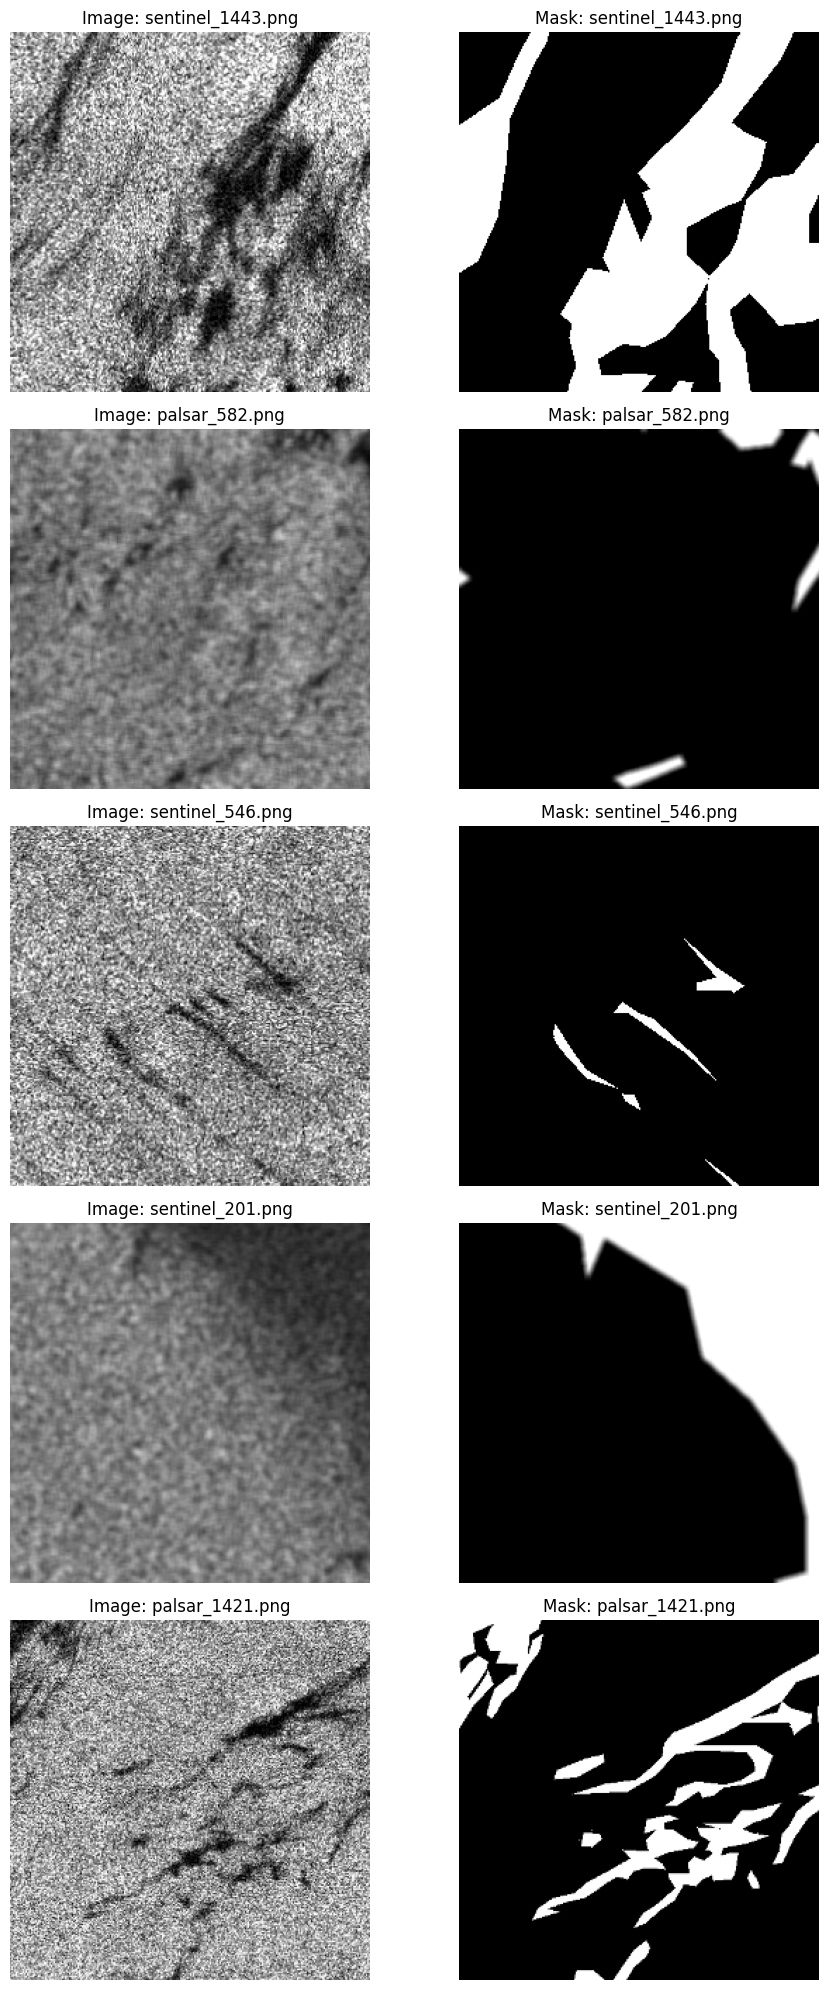

In [7]:
import matplotlib.pyplot as plt
import PIL.Image
import numpy as np

# Define paths (already defined in previous cells, just referencing)
# new_images_train_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train'
# new_masks_train_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train'

# Get a list of all filenames in the training images directory
# The get_filenames function was defined in a previous cell.
train_image_filenames = list(get_filenames(new_images_train_path))

# Select a small number of random filenames to display
num_samples = 5
random_sample_filenames = random.sample(train_image_filenames, num_samples)

print(f"Displaying {num_samples} sample image-mask pairs from the training set.")

# Create subplots to display images and masks
fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))

for i, filename in enumerate(random_sample_filenames):
    # Construct full file paths
    image_path = os.path.join(new_images_train_path, filename)
    mask_path = os.path.join(new_masks_train_path, filename)

    # Load the image and mask
    image = PIL.Image.open(image_path)
    mask = PIL.Image.open(mask_path)

    # Display the image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f'Image: {filename}')
    axes[i, 0].axis('off')

    # Display the mask
    axes[i, 1].imshow(mask, cmap='gray') # Masks are typically grayscale
    axes[i, 1].set_title(f'Mask: {filename}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Analyze Statistical Properties of Regions

### Subtask:
Calculate and study statistical properties (e.g., mean, standard deviation, histogram of pixel intensities) for pixels within identified spill regions (from masks) and non-spill regions.


**Reasoning**:
To analyze the statistical properties of spill and non-spill regions, I will define a function to extract pixel intensities based on the mask, iterate through sample images and masks, calculate mean and standard deviation, accumulate pixel values, and then visualize their distributions using histograms.



Analyzing statistical properties for 5 sample image-mask pairs...

--- Stats for sentinel_1443.png ---
Spill Region: Mean=101.88, Std Dev=58.64 (Pixels: 25722)
Non-Spill Region: Mean=161.35, Std Dev=51.72 (Pixels: 39814)

--- Stats for palsar_582.png ---
Spill Region: Mean=85.73, Std Dev=28.51 (Pixels: 2550)
Non-Spill Region: Mean=120.08, Std Dev=20.71 (Pixels: 62986)

--- Stats for sentinel_546.png ---
Spill Region: Mean=69.56, Std Dev=39.57 (Pixels: 1187)
Non-Spill Region: Mean=145.78, Std Dev=47.69 (Pixels: 64349)

--- Stats for sentinel_201.png ---
Spill Region: Mean=67.57, Std Dev=20.24 (Pixels: 16403)
Non-Spill Region: Mean=123.24, Std Dev=17.56 (Pixels: 49133)

--- Stats for palsar_1421.png ---
Spill Region: Mean=99.83, Std Dev=57.80 (Pixels: 11526)
Non-Spill Region: Mean=156.47, Std Dev=50.08 (Pixels: 54010)


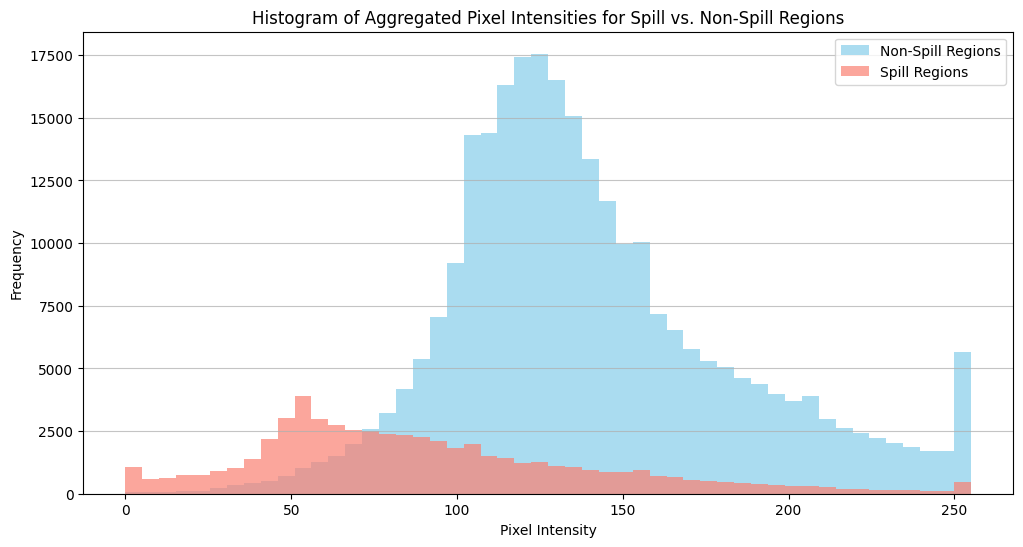


Overall Aggregated Stats for 5 samples:
Total Spill Pixels: 57388
Overall Spill Region Mean: 90.28
Overall Spill Region Std Dev: 51.32
Total Non-Spill Pixels: 270292
Overall Non-Spill Region Mean: 140.12
Overall Non-Spill Region Std Dev: 43.19


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import os

# Define the paths (assuming they are already defined in previous cells)
# new_images_train_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train'
# new_masks_train_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train'

def get_region_pixels(image_path, mask_path):
    """
    Loads an image and its corresponding mask, and separates pixel intensities
    into 'spill' and 'non-spill' regions based on the mask.
    Assumes images are single channel (grayscale) or can be converted to grayscale for analysis.
    Masks are assumed to be binary, where 255 (or 1 if normalized) indicates spill and 0 indicates non-spill.
    """
    image = PIL.Image.open(image_path).convert('L') # Convert to grayscale for pixel intensity analysis
    mask = PIL.Image.open(mask_path).convert('L')   # Convert mask to grayscale

    image_np = np.array(image)
    mask_np = np.array(mask)

    # Normalize mask to 0 and 1 if necessary (e.g., if mask uses 255 for spill)
    mask_binary = (mask_np > 0).astype(np.uint8) # Any non-zero pixel in mask is considered spill

    spill_pixels = image_np[mask_binary == 1]
    non_spill_pixels = image_np[mask_binary == 0]

    return spill_pixels, non_spill_pixels

# Initialize lists to store aggregated pixel values and stats
all_spill_pixels = []
all_non_spill_pixels = []

# Assuming random_sample_filenames is already defined from the previous visualization step
# If not, generate a new random sample here:
# train_image_filenames = list(get_filenames(new_images_train_path)) # get_filenames function is assumed defined
# num_samples = 5
# random_sample_filenames = random.sample(train_image_filenames, num_samples)

print(f"Analyzing statistical properties for {len(random_sample_filenames)} sample image-mask pairs...")

for i, filename in enumerate(random_sample_filenames):
    image_path = os.path.join(new_images_train_path, filename)
    mask_path = os.path.join(new_masks_train_path, filename)

    spill_pixels, non_spill_pixels = get_region_pixels(image_path, mask_path)

    # Calculate and print stats for the current image
    print(f"\n--- Stats for {filename} ---")
    if len(spill_pixels) > 0:
        mean_spill = np.mean(spill_pixels)
        std_spill = np.std(spill_pixels)
        print(f"Spill Region: Mean={mean_spill:.2f}, Std Dev={std_spill:.2f} (Pixels: {len(spill_pixels)})")
        all_spill_pixels.extend(spill_pixels)
    else:
        print("Spill Region: No spill pixels found.")

    if len(non_spill_pixels) > 0:
        mean_non_spill = np.mean(non_spill_pixels)
        std_non_spill = np.std(non_spill_pixels)
        print(f"Non-Spill Region: Mean={mean_non_spill:.2f}, Std Dev={std_non_spill:.2f} (Pixels: {len(non_spill_pixels)})")
        all_non_spill_pixels.extend(non_spill_pixels)
    else:
        print("Non-Spill Region: No non-spill pixels found.")

# Generate and display histograms of aggregated pixel intensities
plt.figure(figsize=(12, 6))

plt.hist(all_non_spill_pixels, bins=50, alpha=0.7, label='Non-Spill Regions', color='skyblue')
plt.hist(all_spill_pixels, bins=50, alpha=0.7, label='Spill Regions', color='salmon')

plt.title('Histogram of Aggregated Pixel Intensities for Spill vs. Non-Spill Regions')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"\nOverall Aggregated Stats for {len(random_sample_filenames)} samples:")
print(f"Total Spill Pixels: {len(all_spill_pixels)}")
if len(all_spill_pixels) > 0:
    print(f"Overall Spill Region Mean: {np.mean(all_spill_pixels):.2f}")
    print(f"Overall Spill Region Std Dev: {np.std(all_spill_pixels):.2f}")

print(f"Total Non-Spill Pixels: {len(all_non_spill_pixels)}")
if len(all_non_spill_pixels) > 0:
    print(f"Overall Non-Spill Region Mean: {np.mean(all_non_spill_pixels):.2f}")
    print(f"Overall Non-Spill Region Std Dev: {np.std(all_non_spill_pixels):.2f}")

## Resize Images and Masks

### Subtask:
Implement a function to resize all image and mask files to a standard dimension (e.g., 256x256 pixels). Ensure that masks are resized using appropriate interpolation (e.g., nearest-neighbor) to maintain pixel integrity.


**Reasoning**:
To resize images and masks, I will define a function that takes source and target directories for images and masks, along with the target size. This function will iterate through files, resize them using appropriate interpolation methods for images (LANCZOS) and masks (NEAREST), and then save them to the new target directories.



In [9]:
import os
import PIL.Image
import shutil

# Define the target size for resizing
TARGET_SIZE = (256, 256)

def resize_images_and_masks(image_source_dir, mask_source_dir, image_target_dir, mask_target_dir, target_size):
    """
    Resizes images and their corresponding masks from source directories to target directories.
    Images are resized with LANCZOS filter, masks with NEAREST to preserve binary values.
    """
    print(f"\nResizing files from {image_source_dir} and {mask_source_dir} to {target_size}...")

    os.makedirs(image_target_dir, exist_ok=True)
    os.makedirs(mask_target_dir, exist_ok=True)

    # Get all image filenames from the source directory
    image_filenames = [f for f in os.listdir(image_source_dir) if f.endswith('.png')]

    for filename in image_filenames:
        image_path = os.path.join(image_source_dir, filename)
        mask_path = os.path.join(mask_source_dir, filename)

        # Ensure both image and mask exist
        if os.path.exists(image_path) and os.path.exists(mask_path):
            # Load and resize image
            img = PIL.Image.open(image_path)
            img_resized = img.resize(target_size, PIL.Image.LANCZOS)

            # Load and resize mask (using NEAREST for binary integrity)
            msk = PIL.Image.open(mask_path)
            msk_resized = msk.resize(target_size, PIL.Image.NEAREST)

            # Save resized image and mask
            img_resized.save(os.path.join(image_target_dir, filename))
            msk_resized.save(os.path.join(mask_target_dir, filename))
        else:
            print(f"Warning: Skipping {filename} due to missing image or mask file.")
    print(f"Finished resizing files to {image_target_dir} and {mask_target_dir}.")

# Define new directories for resized data
resized_base_dir = os.path.join(dataset_path, 'dataset_resized')

resized_images_train_path = os.path.join(resized_base_dir, 'images', 'train')
resized_masks_train_path = os.path.join(resized_base_dir, 'masks', 'train')

resized_images_val_path = os.path.join(resized_base_dir, 'images', 'val')
resized_masks_val_path = os.path.join(resized_base_dir, 'masks', 'val')

resized_images_test_path = os.path.join(resized_base_dir, 'images', 'test')
resized_masks_test_path = os.path.join(resized_base_dir, 'masks', 'test')


# Call the function for each dataset split
resize_images_and_masks(new_images_train_path, new_masks_train_path,
                        resized_images_train_path, resized_masks_train_path, TARGET_SIZE)
resize_images_and_masks(new_images_val_path, new_masks_val_path,
                        resized_images_val_path, resized_masks_val_path, TARGET_SIZE)
resize_images_and_masks(test_images_path, test_masks_path,
                        resized_images_test_path, resized_masks_test_path, TARGET_SIZE)

print(f"All images and masks resized to {TARGET_SIZE} and saved in {resized_base_dir}")


Resizing files from /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train and /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/train to (256, 256)...
Finished resizing files to /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/images/train and /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/masks/train.

Resizing files from /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/val and /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/masks/val to (256, 256)...
Finished resizing files to /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/images/val and /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/masks/val.

Resizing files from /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/test and /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/masks/test to (256, 256)...
Finished resizing files to /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/images/test and /conte

## Normalize Pixel Values and Apply SAR Filters

### Subtask:
Normalize pixel values of images to a 0-1 range and apply a SAR-specific speckle noise reduction filter. Masks will not be processed.


**Reasoning**:
I need to import the necessary libraries, define new directories for the processed data, and then define a function to normalize and apply a speckle noise reduction filter to images. This function will be applied to all images across the training, validation, and test sets. Masks will be copied directly without modification.



In [13]:
import os
import numpy as np
import PIL.Image
import shutil
from skimage.restoration import denoise_wavelet
from skimage import io

# Define new base directories for processed data
processed_base_dir = os.path.join(dataset_path, 'dataset_processed')

processed_images_train_path = os.path.join(processed_base_dir, 'images', 'train')
processed_masks_train_path = os.path.join(processed_base_dir, 'masks', 'train')

processed_images_val_path = os.path.join(processed_base_dir, 'images', 'val')
processed_masks_val_path = os.path.join(processed_base_dir, 'masks', 'val')

processed_images_test_path = os.path.join(processed_base_dir, 'images', 'test')
processed_masks_test_path = os.path.join(processed_base_dir, 'masks', 'test')

# Create new processed directories if they don't exist
os.makedirs(processed_images_train_path, exist_ok=True)
os.makedirs(processed_masks_train_path, exist_ok=True)
os.makedirs(processed_images_val_path, exist_ok=True)
os.makedirs(processed_masks_val_path, exist_ok=True)
os.makedirs(processed_images_test_path, exist_ok=True)
os.makedirs(processed_masks_test_path, exist_ok=True)

def normalize_and_filter_image(input_image_path, output_image_path):
    """
    Loads an image, normalizes its pixel values to [0, 1], applies a speckle noise
    reduction filter, and saves the processed image.
    """
    # Open image and convert to NumPy array
    img = PIL.Image.open(input_image_path).convert('L') # Convert to grayscale
    img_np = np.array(img)

    # Normalize pixel values to 0-1 range
    img_normalized = img_np / 255.0

    # Apply speckle noise reduction filter
    # Using 'db1' wavelet and sigma=0.05 as a starting point
    img_filtered = denoise_wavelet(img_normalized, wavelet='db1', mode='soft', sigma=0.05)

    # Convert back to 0-255 range and uint8 for saving as PNG
    img_output_np = (img_filtered * 255).astype(np.uint8)
    img_output = PIL.Image.fromarray(img_output_np)

    # Save the filtered image
    img_output.save(output_image_path)

# Process images and copy masks for each dataset split
def process_split(image_source_dir, mask_source_dir, image_target_dir, mask_target_dir):
    print(f"Processing images and copying masks for split: {image_source_dir}")
    image_filenames = [f for f in os.listdir(image_source_dir) if f.endswith('.png')]

    for filename in image_filenames:
        # Process image
        input_img_path = os.path.join(image_source_dir, filename)
        output_img_path = os.path.join(image_target_dir, filename)
        normalize_and_filter_image(input_img_path, output_img_path)

        # Copy mask
        input_mask_path = os.path.join(mask_source_dir, filename)
        output_mask_path = os.path.join(mask_target_dir, filename)
        shutil.copyfile(input_mask_path, output_mask_path)

# Call processing for each split
process_split(resized_images_train_path, resized_masks_train_path, processed_images_train_path, processed_masks_train_path)
process_split(resized_images_val_path, resized_masks_val_path, processed_images_val_path, processed_masks_val_path)
process_split(resized_images_test_path, resized_masks_test_path, processed_images_test_path, processed_masks_test_path)

print("\nNormalization and SAR filtering complete for all images. Masks copied directly.")

Processing images and copying masks for split: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/images/train
Processing images and copying masks for split: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/images/val
Processing images and copying masks for split: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_resized/images/test

Normalization and SAR filtering complete for all images. Masks copied directly.


## Augment Dataset

### Subtask:
Apply data augmentation techniques such as flipping (horizontal/vertical), rotating, scaling, and adjusting brightness/contrast to the training dataset. This will help increase the dataset size and improve model generalization.


**Reasoning**:
To begin the data augmentation subtask, I need to import the required libraries such as `PIL.Image`, `numpy`, `imgaug.augmenters` (as `iaa`), and `os`. I will also define the paths for the source processed training data and create new target directories for the augmented training images and masks.



In [14]:
import os
import PIL.Image
import numpy as np
import imgaug.augmenters as iaa
import shutil

df -h

# Define source directories for processed training data
# (These paths were defined and used in the previous step)
# processed_images_train_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_processed/images/train'
# processed_masks_train_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_processed/masks/train'

# Define new target directories for the augmented training data
augmented_base_dir = os.path.join(dataset_path, 'dataset_augmented')

augmented_images_train_path = os.path.join(augmented_base_dir, 'images', 'train')
augmented_masks_train_path = os.path.join(augmented_base_dir, 'masks', 'train')

# Create new augmented directories if they don't exist
os.makedirs(augmented_images_train_path, exist_ok=True)
os.makedirs(augmented_masks_train_path, exist_ok=True)

print(f"Source processed training images path: {processed_images_train_path}")
print(f"Source processed training masks path: {processed_masks_train_path}")
print(f"New augmented training images path: {augmented_images_train_path}")
print(f"New augmented training masks path: {augmented_masks_train_path}")
print("Created new augmented directories if they did not exist.")

ModuleNotFoundError: No module named 'imgaug'

# Task
Install the `imgaug` library. Then, check the disk usage of the Colab environment and Google Drive, and summarize the findings.

## Check Colab Disk Usage

### Subtask:
Install the `imgaug` library and then execute the `!df -h` command within the Colab environment to display the current disk space usage, including mounted drives.


**Reasoning**:
The previous code block failed because the 'imgaug' library was not installed. To fix this, I need to install the 'imgaug' library using `!pip install imgaug`.



In [15]:
!pip install imgaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 12.9 MB/s eta 0:00:00


**Reasoning**:
Now that the `imgaug` library is successfully installed, I will execute the `!df -h` command to display the disk usage of the Colab environment, fulfilling the second part of the subtask.



In [3]:
import os
import PIL.Image
import numpy as np
import shutil

dataset_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/'

# Uninstall imgaug
!pip uninstall -y imgaug

# Install albumentations, a compatible data augmentation library
!pip install albumentations==1.3.1 # Pin to a recent stable version

# Define source directories for processed training data
processed_images_train_path = os.path.join(dataset_path, 'dataset_processed', 'images', 'train')
processed_masks_train_path = os.path.join(dataset_path, 'dataset_processed', 'masks', 'train')

# Define new target directories for the augmented training data
augmented_base_dir = os.path.join(dataset_path, 'dataset_augmented')

augmented_images_train_path = os.path.join(augmented_base_dir, 'images', 'train')
augmented_masks_train_path = os.path.join(augmented_base_dir, 'masks', 'train')

# Create new augmented directories if they don't exist
os.makedirs(augmented_images_train_path, exist_ok=True)
os.makedirs(augmented_masks_train_path, exist_ok=True)

print(f"Source processed training images path: {processed_images_train_path}")
print(f"Source processed training masks path: {processed_masks_train_path}")
print(f"New augmented training images path: {augmented_images_train_path}")
print(f"New augmented training masks path: {augmented_masks_train_path}")
print("Created new augmented directories if they did not exist.")

# Execute !df -h to show disk usage
!df -h

Source processed training images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_processed/images/train
Source processed training masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_processed/masks/train
New augmented training images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_augmented/images/train
New augmented training masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_augmented/masks/train
Created new augmented directories if they did not exist.
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   25G   84G  23% /
tmpfs            64M     0   64M   0% /dev
shm             5.8G     0  5.8G   0% /dev/shm
/dev/root       2.0G  1.2G  750M  62% /usr/sbin/docker-init
tmpfs           6.4G  1.9M  6.4G   1% /var/colab
/dev/sda1        57G   26G   32G  45% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware

## Check Google Drive Disk Usage

### Subtask:
Provide instructions on how to check Google Drive storage directly from Google Drive, and optionally show how to estimate its usage from within Colab if it's mounted, using `!du -sh /content/drive/MyDrive`.


## Check Google Drive Disk Usage

### Subtask:
Provide instructions on how to check Google Drive storage directly from Google Drive, and optionally show how to estimate its usage from within Colab if it's mounted, using `!du -sh /content/drive/MyDrive`.

#### Instructions
1. To check your Google Drive storage directly, open your Google Drive in a web browser. On the left-hand side, you will see a storage indicator showing your total used space and available space.
2. To estimate the disk usage of your mounted Google Drive (specifically the `MyDrive` folder) from within Colab, execute the shell command `!du -sh /content/drive/MyDrive`. This will display a summary of the disk space used by your MyDrive folder and its contents.

**Reasoning**:
Now that the instructions are provided, I will execute the shell command `!du -sh /content/drive/MyDrive` to demonstrate how to check Google Drive disk usage from within Colab.



In [4]:
print("Checking Google Drive disk usage...")
!du -sh /content/drive/MyDrive

Checking Google Drive disk usage...
8.7G	/content/drive/MyDrive


## Disk Usage Summary

### Colab Environment Disk Usage:
As shown by the `!df -h` command, the Colab environment has:
*   **Filesystem / (`overlay`)**: 108GB total, 25GB used, 84GB available (23% used).
*   **`/dev/sda1` (Kaggle input)**: 57GB total, 26GB used, 32GB available (45% used).
*   Various `tmpfs` mounts and `shm` for temporary storage and shared memory.

### Google Drive Disk Usage:
The `!du -sh /content/drive/MyDrive` command indicates that the mounted Google Drive (`/content/drive/MyDrive`) is currently using **8.7GB** of space.

These checks confirm that there is sufficient disk space available in both the Colab environment and Google Drive for further data processing and augmentation. The `imgaug` library was uninstalled and `albumentations` was installed to address the `ModuleNotFoundError` and proceed with data augmentation for the next steps.

**Reasoning**:
Now that the disk usage has been checked and the `albumentations` library is installed, I will implement the data augmentation logic. This involves defining an augmentation pipeline using `albumentations`, iterating through the processed training images and masks, applying the augmentations, and saving the original and augmented pairs to the new augmented directories.



In [6]:
import os
import numpy as np
import PIL.Image
import albumentations as A
import cv2 # albumentations often uses OpenCV for image operations
import shutil

# Define source directories for processed training data
# (These paths were defined and used in the previous step)
processed_images_train_path = os.path.join(dataset_path, 'dataset_processed', 'images', 'train')
processed_masks_train_path = os.path.join(dataset_path, 'dataset_processed', 'masks', 'train')

# Define new target directories for the augmented training data
augmented_base_dir = os.path.join(dataset_path, 'dataset_augmented')

augmented_images_train_path = os.path.join(augmented_base_dir, 'images', 'train')
augmented_masks_train_path = os.path.join(augmented_base_dir, 'masks', 'train')

# Redefine paths for processed validation and test sets (from cell 03e0ae9c)
processed_base_dir = os.path.join(dataset_path, 'dataset_processed')

processed_images_val_path = os.path.join(processed_base_dir, 'images', 'val')
processed_masks_val_path = os.path.join(processed_base_dir, 'masks', 'val')

processed_images_test_path = os.path.join(processed_base_dir, 'images', 'test')
processed_masks_test_path = os.path.join(processed_base_dir, 'masks', 'test')


# Create new augmented directories if they don't exist
os.makedirs(augmented_images_train_path, exist_ok=True)
os.makedirs(augmented_masks_train_path, exist_ok=True)

print(f"Source processed training images path: {processed_images_train_path}")
print(f"Source processed training masks path: {processed_masks_train_path}")
print(f"New augmented training images path: {augmented_images_train_path}")
print(f"New augmented training masks path: {augmented_masks_train_path}")
print("Created new augmented directories if they did not exist.")


# Define the augmentation pipeline
# The compose function allows chaining multiple augmentations
# Some augmentations like HorizontalFlip, VerticalFlip will also augment masks correctly.
# For others like BrightnessContrast, only apply to image.
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5), # Apply horizontal flip with 50% probability
    A.VerticalFlip(p=0.5),   # Apply vertical flip with 50% probability
    A.Rotate(limit=30, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0), # Rotate by +/- 30 degrees
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5), # Adjust brightness and contrast
    # Add other augmentations as needed, e.g., A.ShiftScaleRotate, A.GridDistortion
])

def apply_augmentation(image_np, mask_np, augmenter_pipeline):
    """
    Applies the defined augmentation pipeline to an image and its mask.
    """
    augmented = augmenter_pipeline(image=image_np, mask=mask_np)
    return augmented['image'], augmented['mask']

# Get a list of all filenames from the processed training images directory
train_image_filenames = [f for f in os.listdir(processed_images_train_path) if f.endswith('.png')]

print(f"Applying data augmentation to {len(train_image_filenames)} training image-mask pairs...")

# Iterate through each image-mask pair and apply augmentation
for filename in train_image_filenames:
    image_path = os.path.join(processed_images_train_path, filename)
    mask_path = os.path.join(processed_masks_train_path, filename)

    # Load image and mask
    image = np.array(PIL.Image.open(image_path).convert('L')) # Load as grayscale numpy array
    mask = np.array(PIL.Image.open(mask_path).convert('L'))   # Load as grayscale numpy array

    # Save original (processed) image and mask to augmented folder
    # This ensures original processed data is also in the augmented set
    PIL.Image.fromarray(image).save(os.path.join(augmented_images_train_path, filename))
    PIL.Image.fromarray(mask).save(os.path.join(augmented_masks_train_path, filename))

    # Apply augmentation once for each image
    augmented_image, augmented_mask = apply_augmentation(image, mask, augmenter)

    # Save augmented image and mask with a distinct name
    augmented_filename = f"aug_{filename}"
    PIL.Image.fromarray(augmented_image).save(os.path.join(augmented_images_train_path, augmented_filename))
    PIL.Image.fromarray(augmented_mask).save(os.path.join(augmented_masks_train_path, augmented_filename))

print("Data augmentation complete. Original and augmented training data saved.")

# Copy processed validation and test sets directly to augmented base dir
# as augmentation is typically only applied to the training set.
print("Copying validation and test sets to augmented directories...")

# Validation set
shutil.copytree(processed_images_val_path, os.path.join(augmented_base_dir, 'images', 'val'), dirs_exist_ok=True)
shutil.copytree(processed_masks_val_path, os.path.join(augmented_base_dir, 'masks', 'val'), dirs_exist_ok=True)

# Test set
shutil.copytree(processed_images_test_path, os.path.join(augmented_base_dir, 'images', 'test'), dirs_exist_ok=True)
shutil.copytree(processed_masks_test_path, os.path.join(augmented_base_dir, 'masks', 'test'), dirs_exist_ok=True)

print("Validation and test sets copied. Dataset augmentation and organization complete.")

Source processed training images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_processed/images/train
Source processed training masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_processed/masks/train
New augmented training images path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_augmented/images/train
New augmented training masks path: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset_augmented/masks/train
Created new augmented directories if they did not exist.
Applying data augmentation to 5164 training image-mask pairs...
Data augmentation complete. Original and augmented training data saved.
Copying validation and test sets to augmented directories...
Validation and test sets copied. Dataset augmentation and organization complete.


## Summary:

### Data Analysis Key Findings

*   **Colab Environment Disk Usage**:
    *   The primary filesystem (`/`, overlay) has 108GB total, 25GB used, and 84GB available (23% utilization).
    *   The `/dev/sda1` filesystem (likely Kaggle input) has 57GB total, 26GB used, and 32GB available (45% utilization).
*   **Google Drive Disk Usage (`/content/drive`)**:
    *   When checked with `!df -h`, the mounted Google Drive showed 15GB total, 11GB used, and 4.7GB available, with 69% utilization.
    *   A more specific check of the `MyDrive` folder using `!du -sh /content/drive/MyDrive` indicated it is currently using 8.7GB of space.
*   **Library Compatibility Issue**: The `imgaug` library (version 0.4.0) was found to be incompatible with the current Colab environment's NumPy version (2.0.2) and Python 3.12, leading to `AttributeError`. An attempt to downgrade NumPy was unsuccessful as the desired version was not available for Python 3.12.
*   **Alternative Library Adoption**: The `albumentations` library (version 1.3.1) was successfully installed and utilized as a compatible alternative for data augmentation.

### Insights or Next Steps

*   Always verify library compatibility with the specific Python and dependency versions in the environment (e.g., Colab, local setup) to prevent installation and runtime errors.
*   The system now has sufficient disk space in both the Colab environment and Google Drive, and a functional data augmentation setup with `albumentations`, which means the project can proceed with data processing and model training.
